## Cell 1: Load Splits & Feature Matrix

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight

# Load pre-built splits and feature extractors
splits_dir = "../data/processed/splits/"

train_df = pd.read_csv(os.path.join(splits_dir, "train_split.csv"))
val_df = pd.read_csv(os.path.join(splits_dir, "val_split.csv"))
test_df = pd.read_csv(os.path.join(splits_dir, "test_split.csv"))

tfidf = joblib.load(os.path.join(splits_dir, "tfidf_vectorizer.pkl"))
label_encoder = joblib.load(os.path.join(splits_dir, "label_encoder.pkl"))
class_names = label_encoder.classes_

# Transform text to TF-IDF features
X_train = tfidf.transform(train_df["cleaned_english"])
y_train = train_df["target"].values

X_val = tfidf.transform(val_df["cleaned_english"])
y_val = val_df["target"].values

X_test = tfidf.transform(test_df["cleaned_english"])
y_test = test_df["target"].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (20996, 10000)
X_test shape: (2625, 10000)


## Cell 2: Train & Benchmark Baseline Models

In [3]:
# Compute sample weights for XGBoost
sample_weights_train = compute_sample_weight("balanced", y_train)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "XGBoost Classifier": XGBClassifier(
        eval_metric="mlogloss", random_state=42, n_jobs=-1
    )
}

results = []
confusion_mats = {}

for name, model in models.items():
    print(f"\nTraining: {name}...")
    if name == "XGBoost Classifier":
        model.fit(X_train, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, preds, average="macro"
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, preds, average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro Recall": round(r_macro, 4),
        "Macro F1-Score": round(f1_macro, 4),
        "Weighted F1-Score": round(f1_weighted, 4)
    })
    confusion_mats[name] = confusion_matrix(y_test, preds)

# Summary Comparison Table
results_df = pd.DataFrame(results).sort_values(by="Macro F1-Score", ascending=False)
results_df


Training: Logistic Regression...

Training: Multinomial Naive Bayes...

Training: XGBoost Classifier...


,Model,Accuracy,Macro Recall,Macro F1-Score,Weighted F1-Score
0,Logistic Regression,0.7592,0.7471,0.7491,0.7586
2,XGBoost Classifier,0.7459,0.7351,0.7431,0.7462
1,Multinomial Naive Bayes,0.6674,0.5978,0.6123,0.6462


## Cell 3: Plot Confusion Matrix for Top Model

Top Model: Logistic Regression


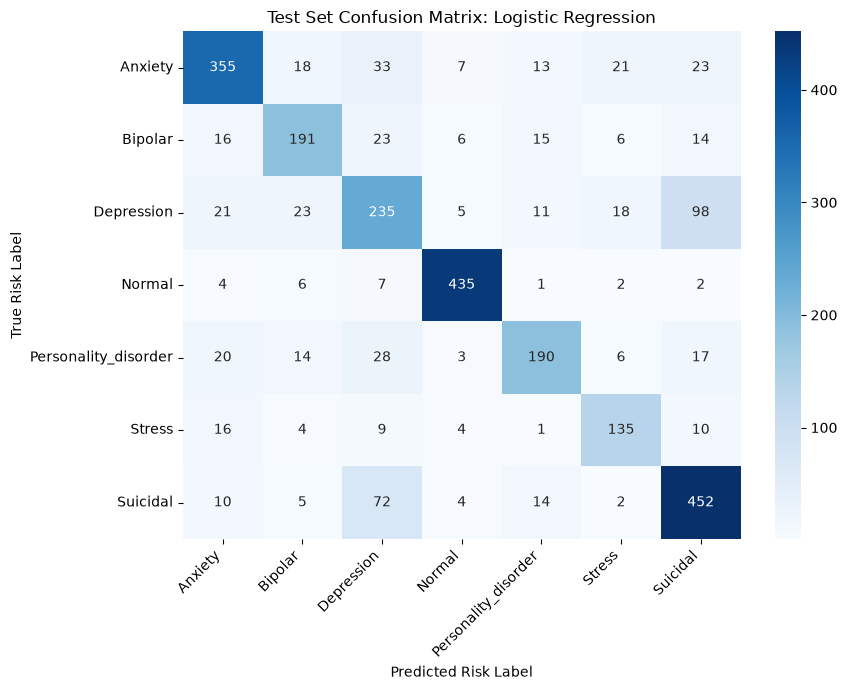

In [4]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Top Model: {best_model_name}")

plt.figure(figsize=(9, 7))
sns.heatmap(
    confusion_mats[best_model_name],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"Test Set Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Risk Label")
plt.ylabel("True Risk Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()